In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

In [12]:
# 1. Setup hyperparameters
BATCH_SIZE = 4
SEQ_LEN = 6       # A small sentence length of 6 tokens
D_MODEL = 32      # Total embedding dimension
NUM_HEADS = 4     # 4 heads means each head gets 8 dimensions (32 / 4 = 8)

device = torch.device("cpu")

# 2. Instantiate the model
# mha_layer = MultiHeadAttention(d_model=D_MODEL, num_heads=NUM_HEADS, dropout=0.0)

# 3. Create a batch of dummy inputs (Batch=4, Seq=6, Dim=32)
# Imagine this represents 4 sentences, each containing 6 words
dummy_batch = torch.randn(BATCH_SIZE, SEQ_LEN, D_MODEL)
print(dummy_batch.shape)

torch.Size([4, 6, 32])


In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

# We need this dummy class so your model can run without throwing a NameError!
class RotaryPositionalEmbedding(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        self.dim = dim

    def forward(self, x: torch.Tensor, seq_len: int) -> torch.Tensor:
        # In a real model, this would rotate the vectors.
        # For this trace, we will keep the shape identical so you can see the flow.
        return x


class MultiHeadAttention(nn.Module):
    def __init__(self, d_model: int, num_heads: int, dropout: float = 0.1):
        super().__init__()
        assert d_model % num_heads == 0, f"d_model ({d_model}) must be divisible by num_heads ({num_heads})."

        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads

        self.qkv_proj = nn.Linear(d_model, 3 * d_model, bias=False)
        self.out_proj = nn.Linear(d_model, d_model, bias=False)
        self.rotary = RotaryPositionalEmbedding(self.head_dim)
        self.attn_dropout = nn.Dropout(dropout)
        self.resid_dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor, mask: torch.Tensor = None) -> torch.Tensor:
        batch_size, seq_len, _ = x.shape
        print(f"--- START FORWARD PASS ---")
        print(f"Input x Shape: {list(x.shape)} | [Batch, Seq_Len, d_model]")

        # ===== STEP 1: Combined Projection =====
        qkv = self.qkv_proj(x)
        print(f"\nStep 1: After qkv_proj: {list(qkv.shape)} | [Batch, Seq_Len, 3 * d_model]")

        # ===== STEP 2: Reshape and Permute =====
        qkv = qkv.reshape(batch_size, seq_len, 3, self.num_heads, self.head_dim)
        print(f"Step 2a: After reshape: {list(qkv.shape)} | [Batch, Seq_Len, 3, Heads, Head_Dim]")
        
        qkv = qkv.permute(2, 0, 3, 1, 4)
        print(f"Step 2b: After permute: {list(qkv.shape)} | [3, Batch, Heads, Seq_Len, Head_Dim]")

        q = qkv[0]
        k = qkv[1]
        v = qkv[2]
        print(f"Step 2c: Unpacked Q: {list(q.shape)} | [Batch, Heads, Seq_Len, Head_Dim]")
        print(f"Step 2c: Unpacked K: {list(k.shape)} | [Batch, Heads, Seq_Len, Head_Dim]")
        print(f"Step 2c: Unpacked V: {list(v.shape)} | [Batch, Heads, Seq_Len, Head_Dim]")

        # ===== STEP 3: Apply Rotary Embeddings =====
        q = self.rotary(q, seq_len)
        k = self.rotary(k, seq_len)

        # ===== STEP 4: Attention Scores =====
        # k.transpose(-2, -1) swaps the last two dimensions: (Seq_Len, Head_Dim) -> (Head_Dim, Seq_Len)
        k_T = k.transpose(-2, -1)
        print(f"\nStep 4a: K Transposed for multiplication: {list(k_T.shape)} | [Batch, Heads, Head_Dim, Seq_Len]")
        
        attn_scores = (q @ k_T) / math.sqrt(self.head_dim)
        print(f"Step 4b: Raw Attention Scores (Q @ K_T): {list(attn_scores.shape)} | [Batch, Heads, Seq_Len, Seq_Len]")

        # ===== STEP 5: Apply Causal Mask =====
        if mask is not None:
            attn_scores = attn_scores.masked_fill(mask == 0, float('-inf'))
            print(f"\nStep 5: Mask applied. Future token scores forced to -inf")

        # ===== STEP 6: Softmax =====
        attn_weights = F.softmax(attn_scores, dim=-1)
        attn_weights = self.attn_dropout(attn_weights)
        print(f"Step 6: Softmax Weights (sum to 1.0 along last dim): {list(attn_weights.shape)}")

        # ===== STEP 7: Weighted Sum of Values =====
        attn_output = attn_weights @ v
        print(f"\nStep 7: Output after weighting Values (weights @ V): {list(attn_output.shape)} | [Batch, Heads, Seq_Len, Head_Dim]")

        # ===== STEP 8: Merge Heads and Project =====
        attn_output = attn_output.transpose(1, 2).contiguous()
        print(f"Step 8a: After transposing back: {list(attn_output.shape)} | [Batch, Seq_Len, Heads, Head_Dim]")
        
        attn_output = attn_output.reshape(batch_size, seq_len, self.d_model)
        print(f"Step 8b: After flattening Heads: {list(attn_output.shape)} | [Batch, Seq_Len, d_model]")

        output = self.out_proj(attn_output)
        output = self.resid_dropout(output)
        print(f"Step 8c: Final Output Projection Shape: {list(output.shape)} | [Batch, Seq_Len, d_model]")
        print(f"--- END FORWARD PASS ---")

        return output


def create_causal_mask(seq_len: int, device: torch.device) -> torch.Tensor:
    mask = torch.tril(torch.ones(seq_len, seq_len, device=device))
    return mask.view(1, 1, seq_len, seq_len)


# ==========================================
# RUNNING THE CODE WITH A BATCH OF 4
# ==========================================

# 1. Setup hyperparameters
BATCH_SIZE = 4
SEQ_LEN = 6       # A small sentence length of 6 tokens
D_MODEL = 32      # Total embedding dimension
NUM_HEADS = 4     # 4 heads means each head gets 8 dimensions (32 / 4 = 8)

device = torch.device("cpu")

# 2. Instantiate the model
mha_layer = MultiHeadAttention(d_model=D_MODEL, num_heads=NUM_HEADS, dropout=0.0)

# 3. Create a batch of dummy inputs (Batch=4, Seq=6, Dim=32)
# Imagine this represents 4 sentences, each containing 6 words
dummy_batch = torch.randn(BATCH_SIZE, SEQ_LEN, D_MODEL)

# 4. Create the causal mask
causal_mask = create_causal_mask(SEQ_LEN, device)
print(f"Causal Mask Shape: {list(causal_mask.shape)} | [1, 1, Seq_Len, Seq_Len]\n")

# 5. Push the batch through the model!
output = mha_layer(dummy_batch, mask=causal_mask)

Causal Mask Shape: [1, 1, 6, 6] | [1, 1, Seq_Len, Seq_Len]

--- START FORWARD PASS ---
Input x Shape: [4, 6, 32] | [Batch, Seq_Len, d_model]

Step 1: After qkv_proj: [4, 6, 96] | [Batch, Seq_Len, 3 * d_model]
Step 2a: After reshape: [4, 6, 3, 4, 8] | [Batch, Seq_Len, 3, Heads, Head_Dim]
Step 2b: After permute: [3, 4, 4, 6, 8] | [3, Batch, Heads, Seq_Len, Head_Dim]
Step 2c: Unpacked Q: [4, 4, 6, 8] | [Batch, Heads, Seq_Len, Head_Dim]
Step 2c: Unpacked K: [4, 4, 6, 8] | [Batch, Heads, Seq_Len, Head_Dim]
Step 2c: Unpacked V: [4, 4, 6, 8] | [Batch, Heads, Seq_Len, Head_Dim]

Step 4a: K Transposed for multiplication: [4, 4, 8, 6] | [Batch, Heads, Head_Dim, Seq_Len]
Step 4b: Raw Attention Scores (Q @ K_T): [4, 4, 6, 6] | [Batch, Heads, Seq_Len, Seq_Len]

Step 5: Mask applied. Future token scores forced to -inf
Step 6: Softmax Weights (sum to 1.0 along last dim): [4, 4, 6, 6]

Step 7: Output after weighting Values (weights @ V): [4, 4, 6, 8] | [Batch, Heads, Seq_Len, Head_Dim]
Step 8a: After 

Some weired diagrams to udnerstand the reshape and permute

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/data'

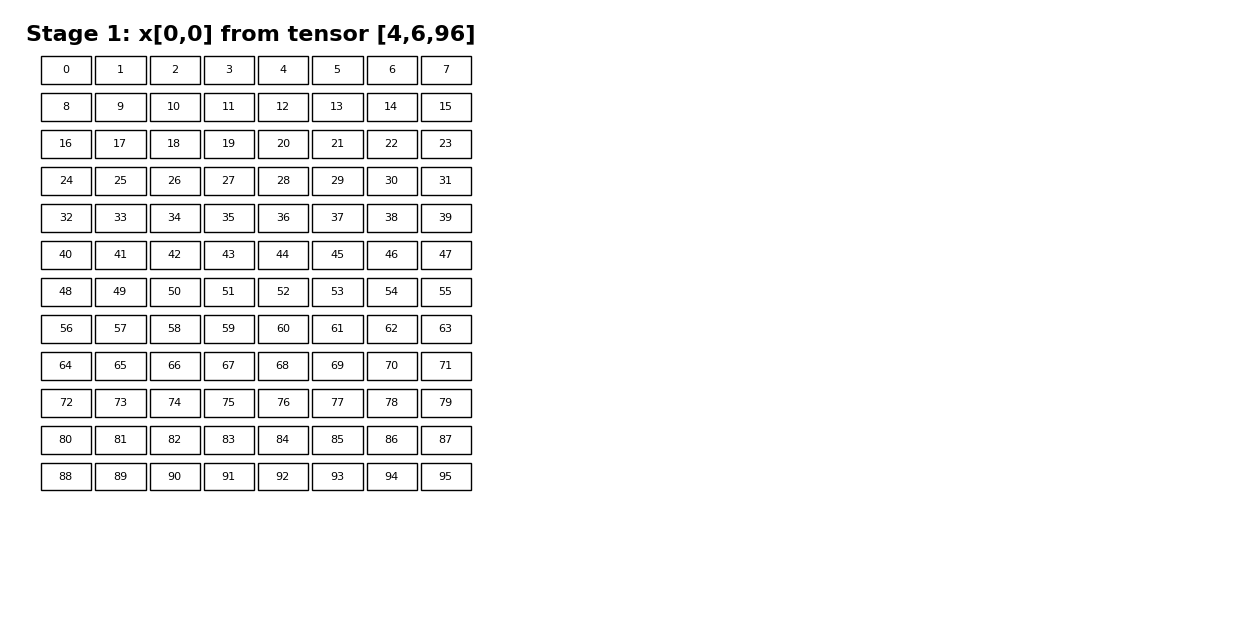

In [13]:
from matplotlib import pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch
from matplotlib.animation import FuncAnimation, PillowWriter
import torch

# Small illustrative example (full 4x6x96 is impossible to draw legibly)
# We visualize ONE token (Batch0, Token0) while keeping the real shapes.
x = torch.arange(4*6*96).reshape(4,6,96)
r = x.reshape(4,6,3,4,8)
p = r.permute(2,0,3,1,4)

fig, ax = plt.subplots(figsize=(16,8))
ax.set_xlim(0,16)
ax.set_ylim(0,10)
ax.axis("off")

def draw_original():
    ax.text(0.2,9.5,"Stage 1: x[0,0] from tensor [4,6,96]",fontsize=16,weight='bold')
    for row in range(12):
        y=8.8-row*0.6
        for col in range(8):
            idx=row*8+col
            ax.add_patch(Rectangle((0.4+col*0.7,y),0.65,0.45,fill=False))
            ax.text(0.72+col*0.7,y+0.22,str(idx),ha='center',va='center',fontsize=8)

def draw_reshape():
    ax.text(5.2,9.5,"Stage 2: reshape -> [4,6,3,4,8]",fontsize=16,weight='bold')
    labels=["Q","K","V"]
    starts=[0,32,64]
    for g,lbl in enumerate(labels):
        x0=5+3.3*g
        ax.text(x0+0.8,8.9,lbl,fontsize=14,weight='bold')
        for h in range(4):
            y=8.2-h*1.2
            ax.text(x0-0.2,y+0.2,f"H{h}",fontsize=9)
            start=starts[g]+h*8
            for k in range(8):
                ax.add_patch(Rectangle((x0+k*0.28,y),0.25,0.25,fill=False))
                ax.text(x0+k*0.28+0.125,y+0.125,str(start+k),fontsize=5,
                        ha='center',va='center')

def draw_permute():
    ax.text(11.5,9.5,"Stage 3: permute -> [3,4,4,6,8]",fontsize=16,weight='bold')
    ax.text(11.5,8.8,"permuted[0] = Query",fontsize=12)
    for h in range(4):
        y=8.0-h*1.2
        ax.text(11.3,y+0.15,f"Head {h}",fontsize=9)
        start=h*8
        for k in range(8):
            ax.add_patch(Rectangle((12+k*0.28,y),0.25,0.25,fill=False))
            ax.text(12+k*0.28+0.125,y+0.125,str(start+k),fontsize=5,
                    ha='center',va='center')

def frame(i):
    ax.clear()
    ax.set_xlim(0,16)
    ax.set_ylim(0,10)
    ax.axis("off")
    if i==0:
        draw_original()
    elif i==1:
        draw_original()
        ax.add_patch(FancyArrowPatch((4.2,5),(5,5),arrowstyle='->',mutation_scale=20))
        draw_reshape()
    elif i==2:
        draw_reshape()
        ax.add_patch(FancyArrowPatch((10.8,5),(11.4,5),arrowstyle='->',mutation_scale=20))
        draw_permute()
    else:
        draw_original()
        draw_reshape()
        draw_permute()

ani=FuncAnimation(fig,frame,frames=4,interval=1800,repeat=True)
gif="/mnt/data/reshape_permute_animation.gif"
ani.save(gif,writer=PillowWriter(fps=1))
plt.close(fig)

with open("/mnt/data/explanation.txt","w") as f:
    f.write(
"""This animation visualizes ONE slice: x[0,0] (one token).
The real tensor still has shape [4,6,96].
Trying to draw all 2304 numbers from the full tensor would be unreadable.
The animation shows exactly how the first 96 numbers are reinterpreted by reshape
and then re-indexed by permute without changing any values."""
)

print(gif)


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/data/reshape_permute_small_visual.png'

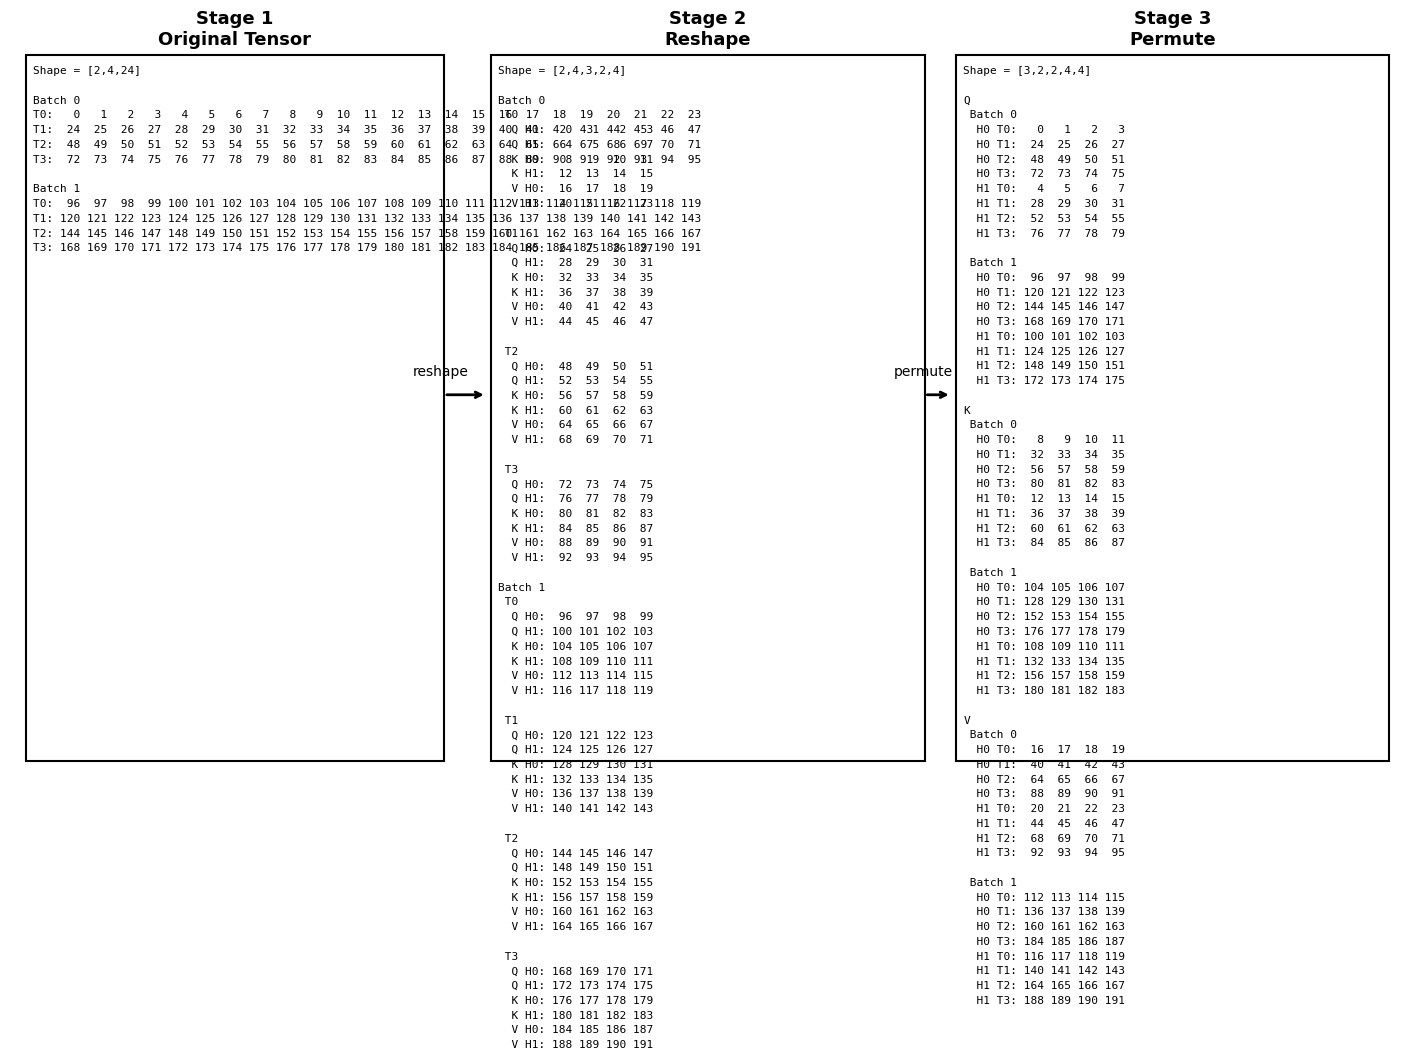

In [15]:
from matplotlib import pyplot as plt
from matplotlib.patches import Rectangle
import torch

BATCH_SIZE=2
SEQ_LEN=4
D_MODEL=8
NUM_HEADS=2
HEAD_DIM=4

x=torch.arange(BATCH_SIZE*SEQ_LEN*(3*D_MODEL)).reshape(BATCH_SIZE,SEQ_LEN,3*D_MODEL)
r=x.reshape(BATCH_SIZE,SEQ_LEN,3,NUM_HEADS,HEAD_DIM)
p=r.permute(2,0,3,1,4)

fig=plt.figure(figsize=(18,10))
ax=plt.gca()
ax.set_xlim(0,18)
ax.set_ylim(0,12)
ax.axis("off")

def draw_block(x0,y0,w,h,title,lines):
    ax.add_patch(Rectangle((x0,y0),w,h,fill=False,linewidth=1.5))
    ax.text(x0+w/2,y0+h+0.15,title,ha="center",fontsize=13,fontweight="bold")
    yy=y0+h-0.3
    for line in lines:
        ax.text(x0+0.1,yy,line,family="monospace",fontsize=8)
        yy-=0.23

# Stage 1
lines=["Shape = [2,4,24]",""]
for b in range(BATCH_SIZE):
    lines.append(f"Batch {b}")
    for t in range(SEQ_LEN):
        vals=" ".join(f"{v:3d}" for v in x[b,t])
        lines.append(f"T{t}: {vals}")
    lines.append("")
draw_block(0.2,0.3,5.4,11,"Stage 1\nOriginal Tensor",lines)

# Stage2
lines=["Shape = [2,4,3,2,4]",""]
for b in range(BATCH_SIZE):
    lines.append(f"Batch {b}")
    for t in range(SEQ_LEN):
        lines.append(f" T{t}")
        for q,name in enumerate(["Q","K","V"]):
            for h in range(NUM_HEADS):
                vals=" ".join(f"{v:3d}" for v in r[b,t,q,h])
                lines.append(f"  {name} H{h}: {vals}")
        lines.append("")
draw_block(6.2,0.3,5.6,11,"Stage 2\nReshape",lines)

# Stage3
lines=["Shape = [3,2,2,4,4]",""]
for q,name in enumerate(["Q","K","V"]):
    lines.append(name)
    for b in range(BATCH_SIZE):
        lines.append(f" Batch {b}")
        for h in range(NUM_HEADS):
            for t in range(SEQ_LEN):
                vals=" ".join(f"{v:3d}" for v in p[q,b,h,t])
                lines.append(f"  H{h} T{t}: {vals}")
        lines.append("")
draw_block(12.2,0.3,5.6,11,"Stage 3\nPermute",lines)

ax.annotate("",xy=(6.15,6),xytext=(5.6,6),arrowprops=dict(arrowstyle="->",lw=2))
ax.annotate("",xy=(12.15,6),xytext=(11.8,6),arrowprops=dict(arrowstyle="->",lw=2))
ax.text(5.2,6.3,"reshape",fontsize=10)
ax.text(11.4,6.3,"permute",fontsize=10)

out="/mnt/data/reshape_permute_small_visual.png"
plt.savefig(out,dpi=220,bbox_inches="tight")
plt.close()

print(out)


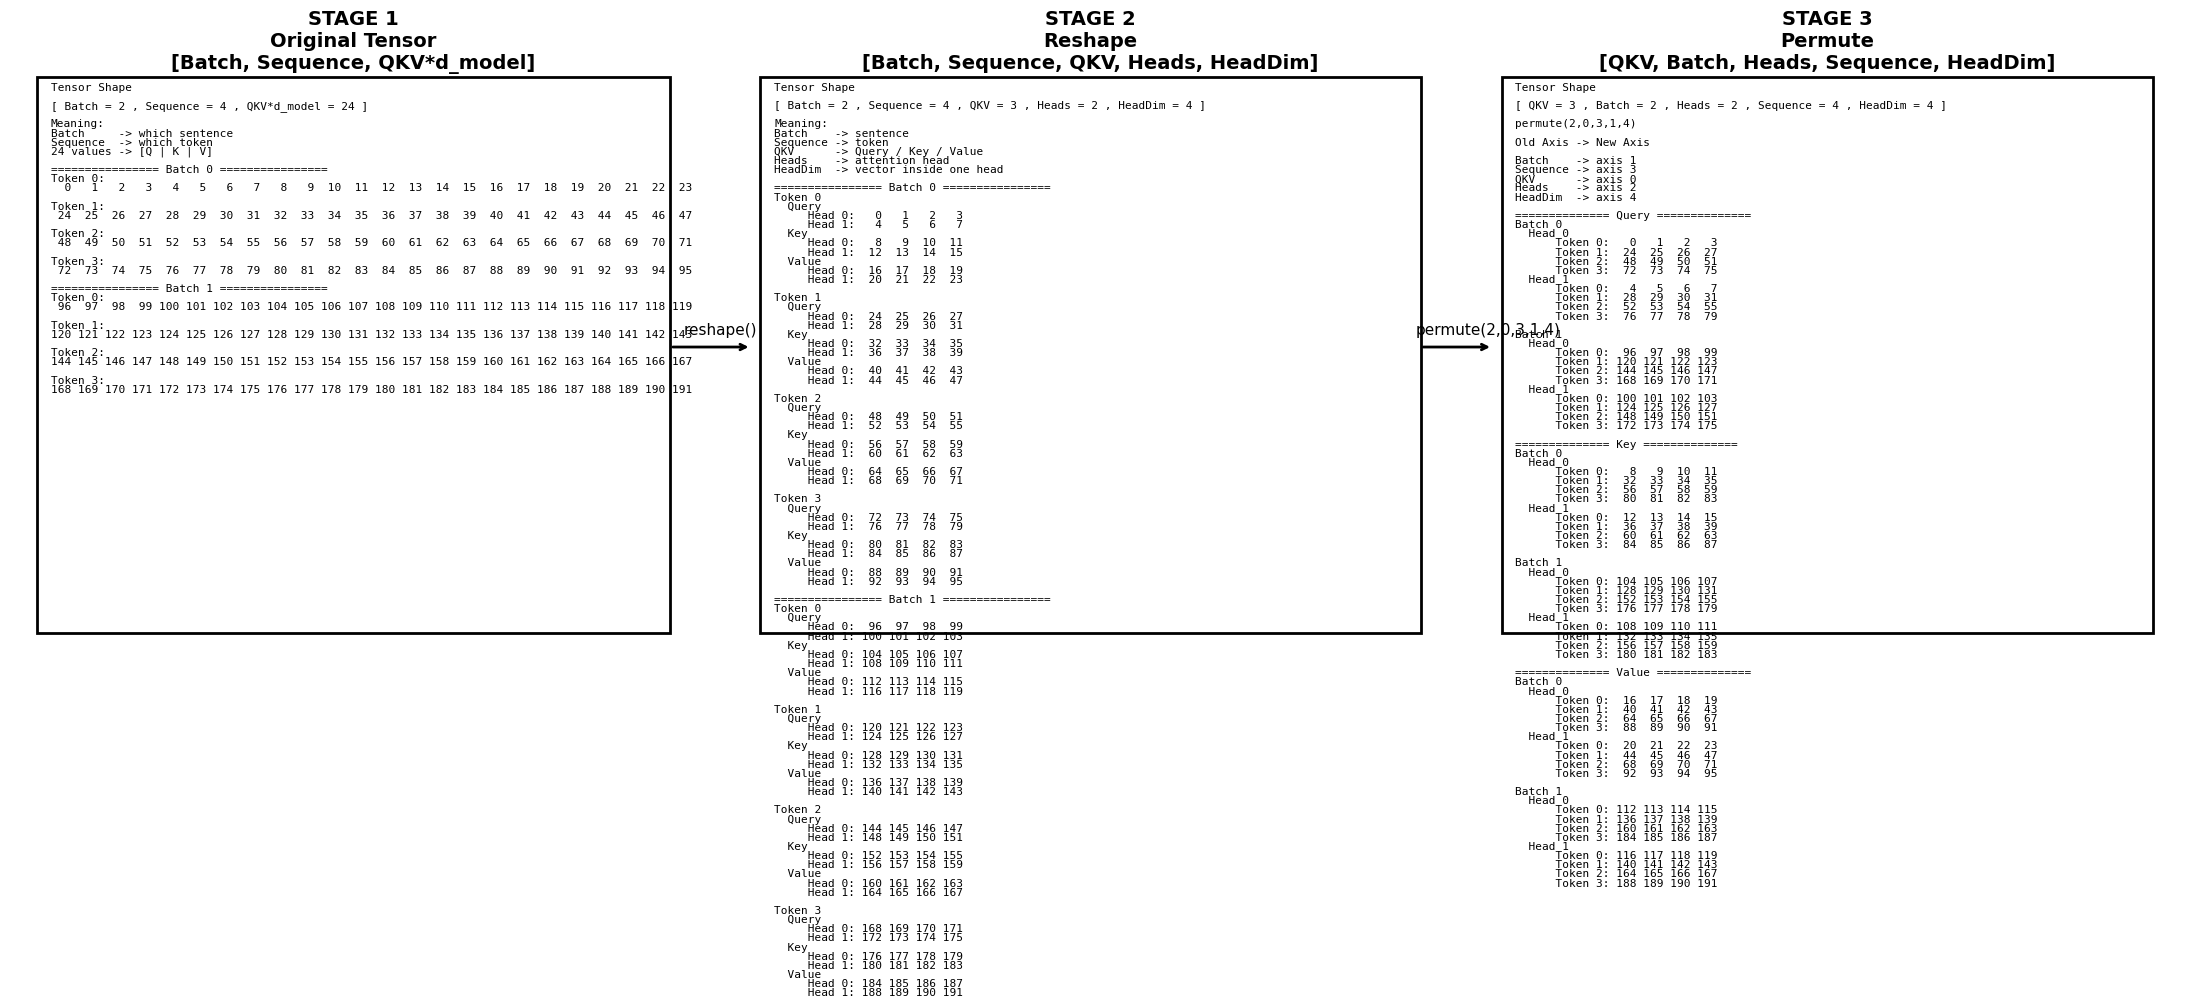

In [16]:
import torch
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# ==========================================================
# Configuration
# ==========================================================
BATCH_SIZE = 2
SEQ_LEN = 4
D_MODEL = 8
NUM_HEADS = 2
HEAD_DIM = D_MODEL // NUM_HEADS

# ==========================================================
# Create Tensor
# ==========================================================
x = torch.arange(BATCH_SIZE * SEQ_LEN * (3 * D_MODEL))
x = x.reshape(BATCH_SIZE, SEQ_LEN, 3 * D_MODEL)

r = x.reshape(
    BATCH_SIZE,
    SEQ_LEN,
    3,
    NUM_HEADS,
    HEAD_DIM
)

p = r.permute(2, 0, 3, 1, 4)

# ==========================================================
# Plot Helpers
# ==========================================================
fig = plt.figure(figsize=(22, 12))
ax = plt.gca()

ax.set_xlim(0, 24)
ax.set_ylim(0, 15)
ax.axis("off")


def draw_block(x0, y0, w, h, title, lines):
    ax.add_patch(Rectangle((x0, y0), w, h,
                           fill=False,
                           linewidth=2))

    ax.text(
        x0 + w / 2,
        y0 + h + 0.2,
        title,
        ha="center",
        fontsize=14,
        fontweight="bold"
    )

    yy = y0 + h - 0.35

    for line in lines:
        ax.text(
            x0 + 0.15,
            yy,
            line,
            fontsize=8,
            family="monospace"
        )
        yy -= 0.23


# ==========================================================
# Stage 1
# ==========================================================
stage1 = [
    "Tensor Shape",
    "",
    "[ Batch = 2 , Sequence = 4 , QKV*d_model = 24 ]",
    "",
    "Meaning:",
    "Batch     -> which sentence",
    "Sequence  -> which token",
    "24 values -> [Q | K | V]",
    "",
]

for b in range(BATCH_SIZE):

    stage1.append(f"================ Batch {b} ================")

    for t in range(SEQ_LEN):

        vals = " ".join(f"{v:3d}" for v in x[b, t])

        stage1.append(f"Token {t}:")
        stage1.append(vals)
        stage1.append("")


draw_block(
    0.3,
    0.3,
    7,
    14,
    "STAGE 1\nOriginal Tensor\n[Batch, Sequence, QKV*d_model]",
    stage1
)

# ==========================================================
# Stage 2
# ==========================================================
stage2 = [
    "Tensor Shape",
    "",
    "[ Batch = 2 , Sequence = 4 , QKV = 3 , Heads = 2 , HeadDim = 4 ]",
    "",
    "Meaning:",
    "Batch    -> sentence",
    "Sequence -> token",
    "QKV      -> Query / Key / Value",
    "Heads    -> attention head",
    "HeadDim  -> vector inside one head",
    "",
]

names = ["Query", "Key", "Value"]

for b in range(BATCH_SIZE):

    stage2.append(f"================ Batch {b} ================")

    for t in range(SEQ_LEN):

        stage2.append(f"Token {t}")

        for q in range(3):

            stage2.append(f"  {names[q]}")

            for h in range(NUM_HEADS):

                vals = " ".join(f"{v:3d}" for v in r[b, t, q, h])

                stage2.append(f"     Head {h}: {vals}")

        stage2.append("")


draw_block(
    8.3,
    0.3,
    7.3,
    14,
    "STAGE 2\nReshape\n[Batch, Sequence, QKV, Heads, HeadDim]",
    stage2
)

# ==========================================================
# Stage 3
# ==========================================================
stage3 = [
    "Tensor Shape",
    "",
    "[ QKV = 3 , Batch = 2 , Heads = 2 , Sequence = 4 , HeadDim = 4 ]",
    "",
    "permute(2,0,3,1,4)",
    "",
    "Old Axis -> New Axis",
    "",
    "Batch    -> axis 1",
    "Sequence -> axis 3",
    "QKV      -> axis 0",
    "Heads    -> axis 2",
    "HeadDim  -> axis 4",
    "",
]

for q in range(3):

    stage3.append(f"============== {names[q]} ==============")

    for b in range(BATCH_SIZE):

        stage3.append(f"Batch {b}")

        for h in range(NUM_HEADS):

            stage3.append(f"  Head {h}")

            for t in range(SEQ_LEN):

                vals = " ".join(f"{v:3d}" for v in p[q, b, h, t])

                stage3.append(f"      Token {t}: {vals}")

        stage3.append("")


draw_block(
    16.5,
    0.3,
    7.2,
    14,
    "STAGE 3\nPermute\n[QKV, Batch, Heads, Sequence, HeadDim]",
    stage3
)

# ==========================================================
# Arrows
# ==========================================================
ax.annotate(
    "",
    xy=(8.2, 7.5),
    xytext=(7.3, 7.5),
    arrowprops=dict(arrowstyle="->", lw=2)
)

ax.text(
    7.45,
    7.8,
    "reshape()",
    fontsize=11
)

ax.annotate(
    "",
    xy=(16.4, 7.5),
    xytext=(15.6, 7.5),
    arrowprops=dict(arrowstyle="->", lw=2)
)

ax.text(
    15.55,
    7.8,
    "permute(2,0,3,1,4)",
    fontsize=11
)

plt.tight_layout()
plt.show()

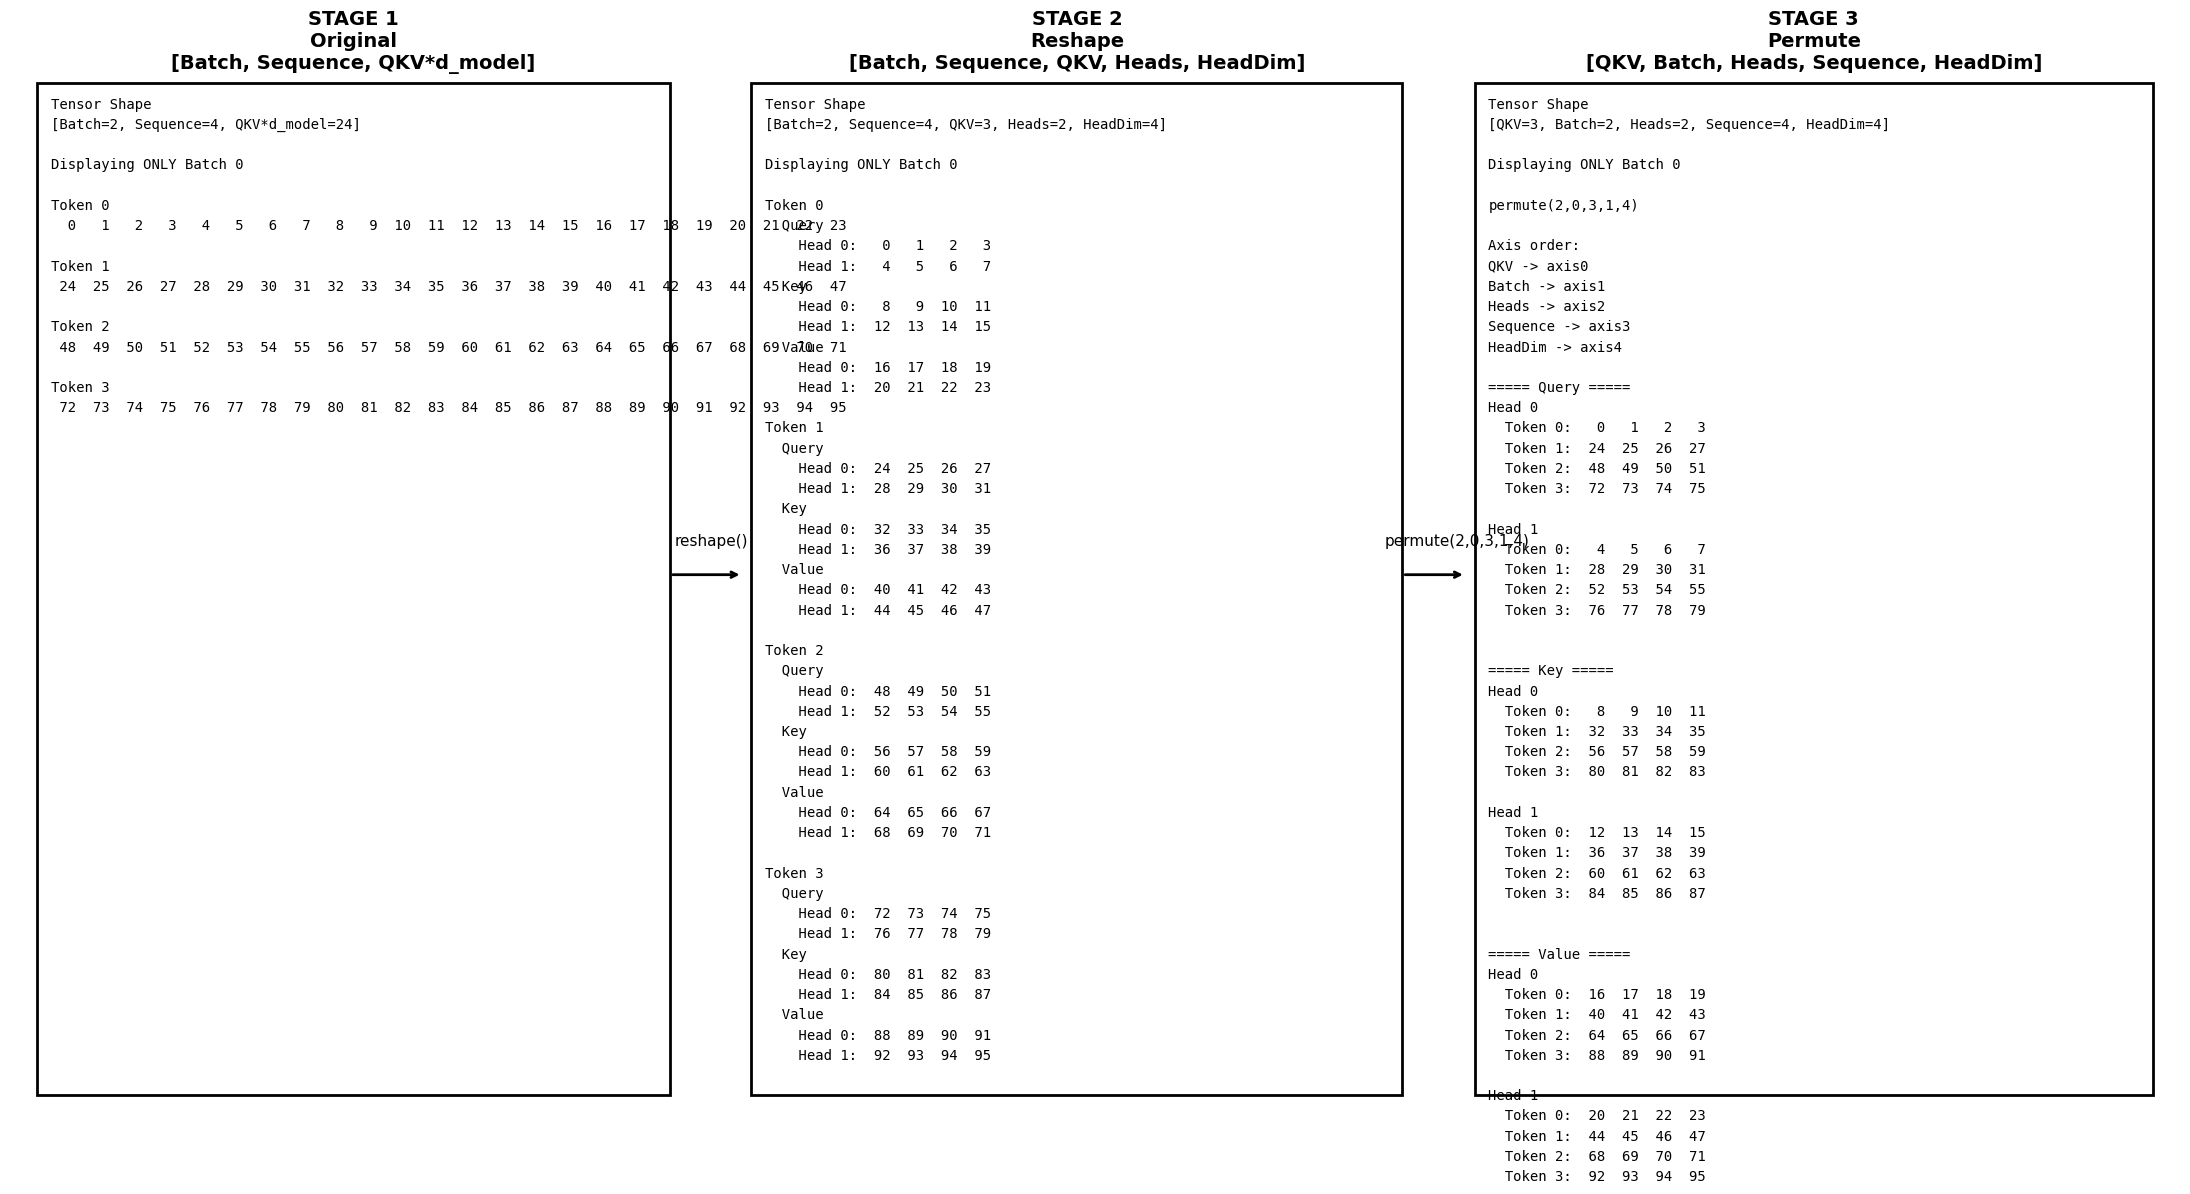

In [1]:

import torch
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# ==========================
# Configuration
# ==========================
BATCH_SIZE = 2
SEQ_LEN = 4
D_MODEL = 8
NUM_HEADS = 2
HEAD_DIM = D_MODEL // NUM_HEADS

# Simulate output of qkv_proj
x = torch.arange(BATCH_SIZE * SEQ_LEN * (3 * D_MODEL))
x = x.reshape(BATCH_SIZE, SEQ_LEN, 3 * D_MODEL)

# Reshape and permute
r = x.reshape(BATCH_SIZE, SEQ_LEN, 3, NUM_HEADS, HEAD_DIM)
p = r.permute(2,0,3,1,4)

fig = plt.figure(figsize=(22,12))
ax = plt.gca()
ax.set_xlim(0,24)
ax.set_ylim(0,15)
ax.axis("off")

def draw_block(x0,y0,w,h,title,lines):
    ax.add_patch(Rectangle((x0,y0),w,h,fill=False,linewidth=2))
    ax.text(x0+w/2,y0+h+0.2,title,ha="center",
            fontsize=14,fontweight="bold")
    yy=y0+h-0.35
    for line in lines:
        ax.text(x0+0.15,yy,line,
                fontsize=10,
                family="monospace")
        yy-=0.28

# ---------------- Stage 1 ----------------
stage1=[
"Tensor Shape",
"[Batch=2, Sequence=4, QKV*d_model=24]",
"",
"Displaying ONLY Batch 0",
""
]

b=0
for t in range(SEQ_LEN):
    stage1.append(f"Token {t}")
    stage1.append(" ".join(f"{v:3d}" for v in x[b,t]))
    stage1.append("")

draw_block(
0.3,0.3,7,14,
"STAGE 1\nOriginal\n[Batch, Sequence, QKV*d_model]",
stage1)

# ---------------- Stage 2 ----------------
stage2=[
"Tensor Shape",
"[Batch=2, Sequence=4, QKV=3, Heads=2, HeadDim=4]",
"",
"Displaying ONLY Batch 0",
""
]

names=["Query","Key","Value"]

for t in range(SEQ_LEN):
    stage2.append(f"Token {t}")
    for q,name in enumerate(names):
        stage2.append(f"  {name}")
        for h in range(NUM_HEADS):
            vals=" ".join(f"{v:3d}" for v in r[b,t,q,h])
            stage2.append(f"    Head {h}: {vals}")
    stage2.append("")

draw_block(
8.2,0.3,7.2,14,
"STAGE 2\nReshape\n[Batch, Sequence, QKV, Heads, HeadDim]",
stage2)

# ---------------- Stage 3 ----------------
stage3=[
"Tensor Shape",
"[QKV=3, Batch=2, Heads=2, Sequence=4, HeadDim=4]",
"",
"Displaying ONLY Batch 0",
"",
"permute(2,0,3,1,4)",
"",
"Axis order:",
"QKV -> axis0",
"Batch -> axis1",
"Heads -> axis2",
"Sequence -> axis3",
"HeadDim -> axis4",
""
]

for q,name in enumerate(names):
    stage3.append(f"===== {name} =====")
    for h in range(NUM_HEADS):
        stage3.append(f"Head {h}")
        for t in range(SEQ_LEN):
            vals=" ".join(f"{v:3d}" for v in p[q,b,h,t])
            stage3.append(f"  Token {t}: {vals}")
        stage3.append("")
    stage3.append("")

draw_block(
16.2,0.3,7.5,14,
"STAGE 3\nPermute\n[QKV, Batch, Heads, Sequence, HeadDim]",
stage3)

ax.annotate("",xy=(8.1,7.5),xytext=(7.3,7.5),
            arrowprops=dict(arrowstyle="->",lw=2))
ax.text(7.35,7.9,"reshape()",fontsize=11)

ax.annotate("",xy=(16.1,7.5),xytext=(15.4,7.5),
            arrowprops=dict(arrowstyle="->",lw=2))
ax.text(15.2,7.9,"permute(2,0,3,1,4)",fontsize=11)

plt.tight_layout()
plt.show()
